# Demo: Computing Indifference Curves
An __indifference curve__ is the set of bundles between which a decision-maker is indifferent: the bundles that give the same level of utility. This example computes and plots indifference curves for three two-good utility functions from the module: linear, Cobb-Douglas, and Leontief.

> __Learning Objectives.__
>
> This example shows how the form of a utility function sets the shape of its indifference curves:
> * __Level sets of a utility function:__ Compute the indifference curve of a two-good utility function by solving $U(x_{1},x_{2})=U^{\star}$ for $x_{2}$ as a function of $x_{1}$.
> * __Substitutes, complements, and mixtures:__ Compare the straight lines of a linear utility, the convex curves of a Cobb-Douglas utility, and the L-shaped corners of a Leontief utility.
> * __Utility levels and the preference map:__ Trace a family of indifference curves by varying $U^{\star}$ and show that curves farther from the origin correspond to higher utility.

Let's get started.
___

## Theory
For a utility function $U:\mathcal{X}\rightarrow\mathbb{R}$ and a fixed level $U^{\star}$, the indifference curve is the level set
$$
U(x_{1},\ldots,x_{m}) = U^{\star}.
$$
Varying $U^{\star}$ traces a family of curves. Each curve collects the bundles the agent ranks equally, and curves farther from the origin correspond to higher utility.

For two goods, we compute a curve by fixing $U^{\star}$ and solving $U(x_{1},x_{2})=U^{\star}$ for $x_{2}$ as a function of $x_{1}$. The form of $U$ sets the shape of the curve: a linear utility gives straight lines, a Cobb-Douglas utility gives curves convex to the origin, and a Leontief utility gives L-shaped corners. Each section below builds one utility model with `build(...)`, evaluates its indifference curve at several levels $U^{\star}$ with `indifference(...)`, and plots the family.
___

## Setup
This example uses functions defined in the `src` directory and a small set of external packages. The `include(...)` call below runs `Include.jl`, which activates the local project environment, loads the packages, and includes our code. The first run may take a few minutes while packages are installed and precompiled.

In [1]:
include("Include.jl");

  Activating project at `~/Desktop/julia_work/CHEME-140-eCornell-Repository/CHEME-140-eCornell-Repository/courses/CHEME-145/module-1`


## Linear Utility: Perfect Substitutes
A __linear__ utility function values each good at a constant rate:
$$
U(\mathbf{x}) = \boldsymbol{\alpha}^{\top}\mathbf{x} = \sum_{i=1}^{m}\alpha_{i}x_{i},\qquad \alpha_{i}\geq 0,\; x_{i}\geq 0.
$$
For two goods, the indifference curve $\alpha_{1}x_{1}+\alpha_{2}x_{2}=U^{\star}$ solves to
$$
x_{2} = \frac{U^{\star}-\alpha_{1}x_{1}}{\alpha_{2}},
$$
a straight line with slope $-\alpha_{1}/\alpha_{2}$. The slope is constant, so the agent trades good 1 for good 2 at a fixed rate regardless of the current bundle: the goods are __perfect substitutes__.

We build a `MyLinearUtilityFunction` with `build(...)`, then call `indifference(...)` for several utility levels $U^{\star}$.

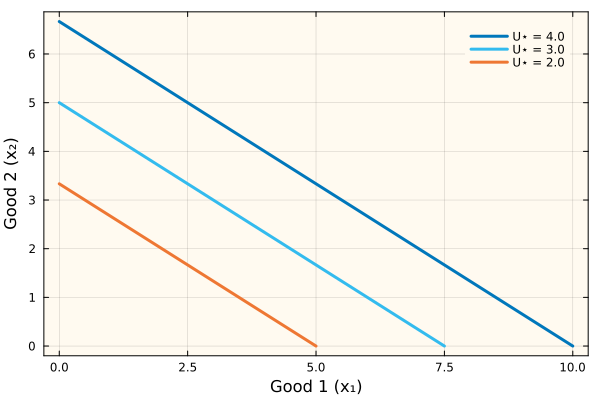

In [2]:
# build a linear utility model -
linear_model = build(MyLinearUtilityFunction, (
    α = [0.4, 0.6],
));

# plot one indifference curve per utility level -
levels = [4.0, 3.0, 2.0];
p = plot();
for (i, Ustar) ∈ enumerate(levels)
    x₁ = range(0.0, stop = Ustar/linear_model.α[1], length = 200) |> collect;
    X = indifference(linear_model, Ustar, x₁);
    plot!(p, X[:,1], X[:,2], label = "U⋆ = $(Ustar)", lw = 3, c = colors[i],
        bg = "floralwhite", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent);
end
xlabel!(p, "Good 1 (x₁)");
ylabel!(p, "Good 2 (x₂)");
current()

## Cobb-Douglas Utility: A Mixture
The __Cobb-Douglas__ utility function is the product of the goods, each raised to an exponent:
$$
U(\mathbf{x}) = \prod_{i=1}^{m}x_{i}^{\alpha_{i}},\qquad \sum_{i=1}^{m}\alpha_{i}=1,\; \alpha_{i}\geq 0,\; x_{i}\geq 0.
$$
For two goods, the indifference curve $x_{1}^{\alpha_{1}}x_{2}^{\alpha_{2}}=U^{\star}$ solves to
$$
x_{2} = \left(\frac{U^{\star}}{x_{1}^{\alpha_{1}}}\right)^{1/\alpha_{2}}.
$$
The curve is convex to the origin: the agent gives up less of good 2 for a unit of good 1 as good 1 becomes plentiful. The product form requires both goods to be positive to obtain positive utility, so neither good alone is enough.

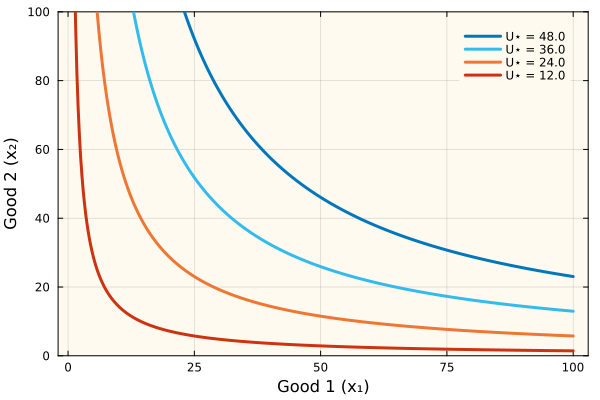

In [3]:
# build a Cobb-Douglas utility model -
cobb_model = build(MyCobbDouglasUtilityFunction, (
    α = [0.5, 0.5],
));

# plot one indifference curve per utility level -
levels = [48.0, 36.0, 24.0, 12.0];
p = plot();
for (i, Ustar) ∈ enumerate(levels)
    x₁ = range(1.0, stop = 100.0, length = 400) |> collect;
    X = indifference(cobb_model, Ustar, x₁);
    plot!(p, X[:,1], X[:,2], label = "U⋆ = $(Ustar)", lw = 3, c = colors[i],
        bg = "floralwhite", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent, ylims = (0.0, 100.0));
end
xlabel!(p, "Good 1 (x₁)");
ylabel!(p, "Good 2 (x₂)");
current()

## Leontief Utility: Perfect Complements
The __Leontief__ utility function values goods in fixed proportions:
$$
U(\mathbf{x}) = \min\left(\frac{x_{1}}{\alpha_{1}},\ldots,\frac{x_{n}}{\alpha_{n}}\right),\qquad \alpha_{i}>0,\; x_{i}\geq 0.
$$
Utility is set by the scarcest good relative to its proportion $\alpha_{i}$; adding more of any other good does not raise utility. For two goods, the indifference curve for level $U^{\star}$ is the L-shaped corner with vertex at $(\alpha_{1}U^{\star},\alpha_{2}U^{\star})$. The goods are __perfect complements__: they are useful only together, in the ratio $\alpha_{1}:\alpha_{2}$.

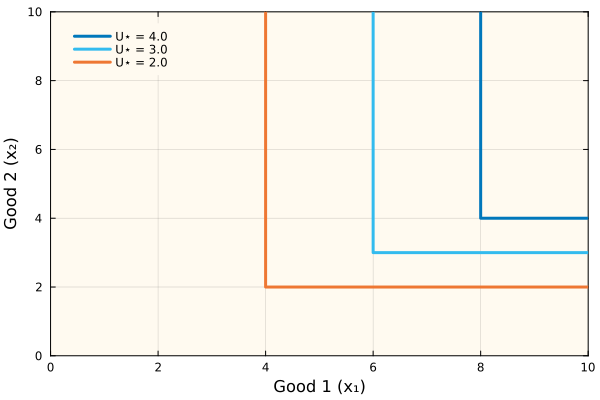

In [4]:
# build a Leontief utility model -
leontief_model = build(MyLeontiefUtilityFunction, (
    α = [2.0, 1.0],
));

# plot one indifference curve per utility level -
levels = [4.0, 3.0, 2.0];
p = plot();
for (i, Ustar) ∈ enumerate(levels)
    X = indifference(leontief_model, Ustar; xmax = 10.0, ymax = 10.0);
    plot!(p, X[:,1], X[:,2], label = "U⋆ = $(Ustar)", lw = 3, c = colors[i],
        bg = "floralwhite", background_color_outside = "white",
        framestyle = :box, fg_legend = :transparent,
        xlims = (0.0, 10.0), ylims = (0.0, 10.0));
end
xlabel!(p, "Good 1 (x₁)");
ylabel!(p, "Good 2 (x₂)");
current()

## Summary
This example computed indifference curves as level sets of three utility functions. The form of the utility function fixes the shape of its curves: linear utility gives straight lines, Cobb-Douglas gives convex curves, and Leontief gives L-shaped corners.

> __Key takeaways:__
>
> 1. __An indifference curve is a level set.__ For a fixed utility level $U^{\star}$, the curve is the set of bundles solving $U(x_{1},x_{2})=U^{\star}$; solving for $x_{2}$ as a function of $x_{1}$ gives a curve that can be plotted.
> 2. __Shape encodes substitutability.__ Straight lines mark perfect substitutes with a constant trade-off, convex curves mark goods valued as a mixture with a trade-off that changes across the bundle, and L-shaped corners mark perfect complements used in fixed proportions.
> 3. __Higher curves mean higher utility.__ Increasing $U^{\star}$ moves the curve away from the origin, so the family of curves orders bundles by preference.

The shape of an indifference curve sets how a budget line meets it, which fixes the optimal bundle in the constrained-choice example.
___

### Additional Resources
* Mas-Colell, A., Whinston, M. D., & Green, J. R. (1995). _Microeconomic Theory_. Oxford University Press.
* Varian, H. R. (1992). _Microeconomic Analysis_ (3rd ed.). W. W. Norton.